# Clase: Consultas SQL y análisis con Pandas

En esta clase aprenderemos a:
- Crear una base de datos en SQLite desde Python
- Almacenar y consultar datos usando SQL
- Importar los resultados a DataFrames
- Combinar datos con `merge()` de Pandas para análisis

---

SQLite Conecta directamente a una base de datos SQLite.

Ventajas:
- Es parte de la biblioteca estándar de Python (no necesitas instalar nada).
- Muy simple y directo.
- Ideal si vas a trabajar tú directamente con SQL (como cursor.execute(...)).

Limitaciones:
- No se integra automáticamente con pandas.to_sql() o read_sql() sin que tú gestiones conexiones o cursores manualmente.












In [3]:
import sqlite3
import pandas as pd

# Crear base en memoria y cursor
conn = sqlite3.connect(":memory:")
cursor = conn.cursor()

## 1. Crear tablas y poblar la base con datos de ejemplo

In [2]:
# Crear tablas
cursor.execute("""
CREATE TABLE estudiantes (
    id INTEGER PRIMARY KEY,
    nombre TEXT,
    carrera TEXT
);
""")

cursor.execute("""
CREATE TABLE calificaciones (
    id INTEGER PRIMARY KEY,
    estudiante_id INTEGER,
    materia TEXT,
    calificacion INTEGER,
    FOREIGN KEY(estudiante_id) REFERENCES estudiantes(id)
);
""")

In [20]:
# Insertar datos
estudiantes_data = [
    (1, 'Ana', 'Economía'),
    (2, 'Luis', 'Ciencia Política'),
    (3, 'Sofía', 'Economía'),
    (4, 'Carlos', 'Relaciones Internacionales')
]

calificaciones_data = [
    (1, 1, 'Estadística', 85),
    (2, 1, 'Econometría', 90),
    (3, 2, 'Teoría Política', 78),
    (4, 2, 'Estadística', 82),
    (5, 3, 'Economía I', 88),
    (6, 3, 'Estadística', 91),
    (7, 4, 'Derecho Internacional', 75)
]

cursor.executemany("INSERT INTO estudiantes VALUES (?, ?, ?);", estudiantes_data)
cursor.executemany("INSERT INTO calificaciones VALUES (?, ?, ?, ?);", calificaciones_data)
conn.commit()

## 2. Consultar datos y analizarlos con Pandas

In [ ]:
# Leer desde SQL
df_estudiantes = pd.read_sql("SELECT * FROM estudiantes", conn)
df_calificaciones = pd.read_sql("SELECT * FROM calificaciones", conn)

df_estudiantes.head()

,id,nombre,carrera
0,1,Ana,Economía
1,2,Luis,Ciencia Política
2,3,Sofía,Economía
3,4,Carlos,Relaciones Internacionales


In [22]:
df_calificaciones.head()

,id,estudiante_id,materia,calificacion
0,1,1,Estadística,85
1,2,1,Econometría,90
2,3,2,Teoría Política,78
3,4,2,Estadística,82
4,5,3,Economía I,88


## 3. Combinar tablas: `merge()` de Pandas

In [25]:
df_merged = pd.merge(df_calificaciones, df_estudiantes,
                     left_on='estudiante_id', right_on='id',
                     suffixes=('_calif', '_est'))

df_merged

,id_calif,estudiante_id,materia,calificacion,id_est,nombre,carrera
0,1,1,Estadística,85,1,Ana,Economía
1,2,1,Econometría,90,1,Ana,Economía
2,3,2,Teoría Política,78,2,Luis,Ciencia Política
3,4,2,Estadística,82,2,Luis,Ciencia Política
4,5,3,Economía I,88,3,Sofía,Economía
5,6,3,Estadística,91,3,Sofía,Economía
6,7,4,Derecho Internacional,75,4,Carlos,Relaciones Internacionales


In [23]:
# Cerrar conexión  
# Es buena práctica cerrar la conexión a la base de datos   
# cuando ya no se necesita.
conn.close() 

In [ ]:
df_merged.to_csv('calificaciones_estudiantes.csv', index=False) #esta linea sirve para guardar el dataframe6

## 4. Análisis y ejercicios

1. ¿Cuál es el promedio por carrera?


In [27]:
df_merged.groupby('carrera')['calificacion'].mean()

carrera
Ciencia Política              80.0
Economía                      88.5
Relaciones Internacionales    75.0
Name: calificacion, dtype: float64

2. ¿Qué estudiante tiene mejor promedio?


In [28]:
promedios_estudiantes = df_merged.groupby('nombre')['calificacion'].mean()
mejor_estudiante = promedios_estudiantes.idxmax()
mejor_promedio = promedios_estudiantes.max()

print(f"El estudiante con mejor promedio es {mejor_estudiante} con {mejor_promedio}")


El estudiante con mejor promedio es Sofía con 89.5


3. ¿Cuál es la materia más cursada?


In [29]:
materia_mas_cursada = df_merged['materia'].value_counts().idxmax()
conteo = df_merged['materia'].value_counts().max()

print(f"La materia más cursada es {materia_mas_cursada} con {conteo} inscripciones")


La materia más cursada es Estadística con 3 inscripciones


4. Hacer un gráfico de barras del promedio por estudiante usando `groupby()` + `plot()`


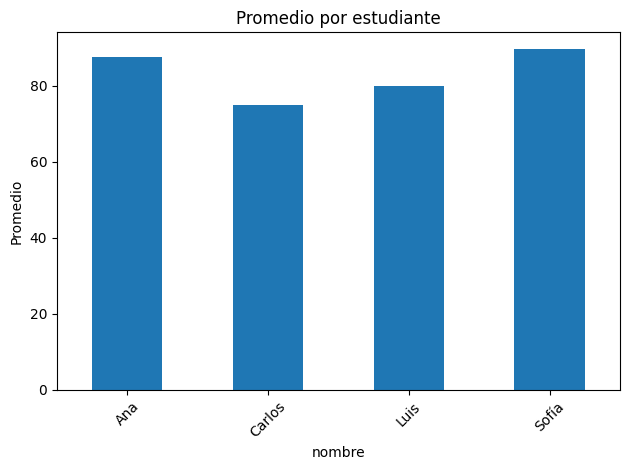

In [30]:
import matplotlib.pyplot as plt

promedios_estudiantes.plot(kind='bar', title='Promedio por estudiante', ylabel='Promedio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


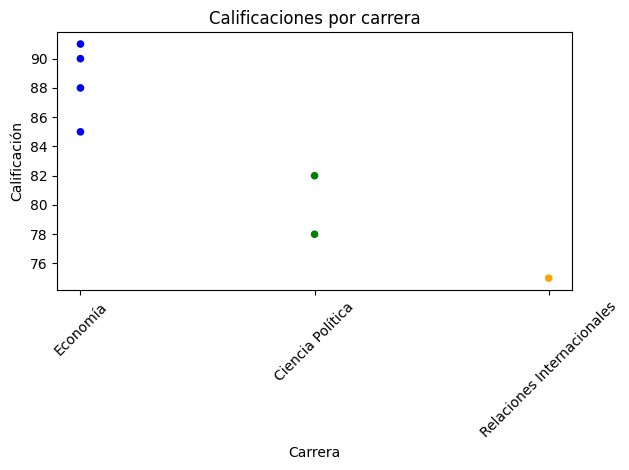

In [31]:
# Gráfico de calificaciones por carrera
color_map = {
    'Economía': 'blue',
    'Ciencia Política': 'green',
    'Relaciones Internacionales': 'orange'
}   
df_merged['color'] = df_merged['carrera'].map(color_map)


df_merged.plot(
    kind='scatter',
    x='carrera',
    y='calificacion',
    c=df_merged['color'],
    title='Calificaciones por carrera',
    xlabel='Carrera',
    ylabel='Calificación'
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

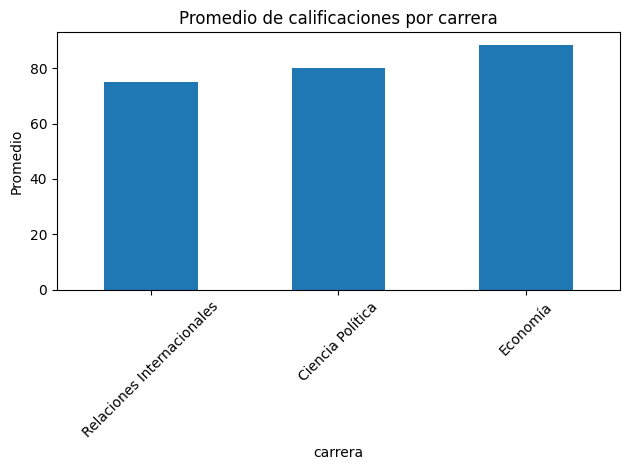

In [32]:


df_carrera = df_merged.groupby('carrera')['calificacion'].mean().sort_values() 
df_carrera.plot(kind='bar', title='Promedio de calificaciones por carrera', ylabel='Promedio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
